<a href="https://colab.research.google.com/github/claramanolache/ML_Intro/blob/main/Week_9_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Instructions

For this assignment, you will use the MNIST dataset to apply clustering methods to discover patterns in data, compare their performance using Silhouette scores, and investigate how dimensionality reduction affects clustering results.

**Do not delete any instructor-provided cells from this Notebook.** If you accidentally delete a cell, you can either undo the action or load a copy of the original assignment Notebook in a new browser tab and copy over the missing cells.

**You can add cells to this Notebook.** To add a markdown (text) cell, hover your cursor beneath the cell where you want to insert and click the "+Text" button. To add a Python (code) cell, click the "+Code" button.

### Steps
- Prepare the data
  - Truncate (see below)
  - Perform scaling
- Build clustering models
  - First without dimensionality reduction
  - Second with Principal Component Analysis
- Evaluate the results
  - Using the Adjusted Rand Index (see below)
  - Using Silhouette scores
  - Visualize pairs of principal components using the provided plotting code
- Report your findings

## Import Libraries

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import cluster
from sklearn import datasets
from sklearn import decomposition
from sklearn import metrics
from sklearn import model_selection
from sklearn import preprocessing

In [71]:
seed = 42

## Revisiting the MNIST Dataset

The MNIST dataset contains 70,000 grayscale images of handwritten digits (0-9). Each image is 28x28 pixels, resulting in 784 features. For computational efficiency, we will use a subset of the data.

### Load the Data

#### Downloading with the Keras Interface

In [72]:
from tensorflow import keras

(X_train_keras, y_train_keras), (X_test_keras, y_test_keras) = keras.datasets.mnist.load_data()

X = np.concatenate((X_train_keras, X_test_keras), axis=0)
y = np.concatenate((y_train_keras, y_test_keras), axis=0)

X = X.reshape(X.shape[0], -1)

X.shape, y.shape

((70000, 784), (70000,))

#### Downloading with the scikit-learn Interface (via OpenML)

In [73]:
#bunch_obj = datasets.fetch_openml("mnist_784", as_frame=False)
#X, y = bunch_obj.data, bunch_obj.target
#X.shape, y.shape

### Truncate the Data

For expediency, you do not need to use the entire dataset. You can increase the sample size (number of rows) below, but do not decrease it.

In [74]:
sample_size = 5000

In [75]:
X_trunc, y_trunc = X[:sample_size], y[:sample_size]
X_trunc.shape, y_trunc.shape

((5000, 784), (5000,))

### Preprocessing

Scale the data for optimal performance.

In [76]:
scaler = preprocessing.StandardScaler()
X_scaled = scaler.fit_transform(X_trunc)

### Clustering with Original Features

Train each of the 3 models:
- K-Means Clustering
- DBSCAN
- Hierarchical Agglomerative Clustering

For models that require specifying a number of clusters, recall that there are 10 classes in this dataset.

#### Adjusted Rand Index

As an additional metric to evaluate clusters, code to compute the Adjusted Rand Index has been provided. This metric compares the true labels (which we have for MNIST) against the clusters created by each algorithm. Values of this metric range from -0.5 to 1.0, where 1.0 represents an optimal outcome.

#### K-Means

In [77]:
kmeans = cluster.KMeans(n_clusters=10, random_state=seed, n_init='auto')
labels_kmeans = kmeans.fit_predict(X_scaled)

In [78]:
metrics.adjusted_rand_score(y_trunc, labels_kmeans)

0.28549263781143597

#### DBSCAN

In [79]:
dbscan = cluster.DBSCAN(eps=15, min_samples=20)
labels_dbscan = dbscan.fit_predict(X_scaled)

In [80]:
metrics.adjusted_rand_score(y_trunc, labels_dbscan)

0.06031849975027725

#### Agglomerative

In [81]:
agglomerative = cluster.AgglomerativeClustering(n_clusters=10)
labels_agglom = agglomerative.fit_predict(X_scaled)

In [82]:
metrics.adjusted_rand_score(y_trunc, labels_agglom)

0.40206863188272335

### Compare Silhouette Scores

In [83]:
pd.Series({
  "K-Means": metrics.silhouette_score(X_scaled, labels_kmeans),
  "DBSCAN": metrics.silhouette_score(X_scaled, labels_dbscan),
  "Agglomerative": metrics.silhouette_score(X_scaled, labels_agglom)
}).rename("score").sort_values(ascending=False)

,score
K-Means,0.017585
Agglomerative,-0.027862
DBSCAN,-0.112868


## Clustering with Principal Component Analysis

Principal Component Analysis reduces the dimensionality of the data while preserving as much variance as possible.

For this exercise, rather than specifying a specific number of principal components, instead use `n_components` to retain 95% of the data's variance.

In [84]:
pca = decomposition.PCA(n_components=.95, random_state=seed)
X_pca_transformed = pca.fit_transform(X_scaled)
pca_component_names = [f"PC{i+1}" for i in range(pca.n_components_)]
X_pca = pd.DataFrame(
    X_pca_transformed,
    columns=pca_component_names
)
X_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC255,PC256,PC257,PC258,PC259,PC260,PC261,PC262,PC263,PC264
0,-1.183818,-4.746649,-0.617645,7.376369,1.665831,1.530760,0.622300,1.037407,0.723218,0.233475,...,-1.441732,0.051630,0.348583,0.587770,-0.548461,-0.624648,0.067022,0.143607,-0.143868,-0.090486
1,8.342006,-7.066931,-5.279512,2.106282,-0.566230,-5.133337,-0.964161,2.296466,1.126451,-2.243343,...,-0.126109,0.264024,0.515693,-0.065763,-0.325491,-0.089410,0.105598,0.056332,-0.476341,-0.078737
2,2.637481,10.662147,-3.538522,-0.665407,-3.104848,4.183638,-18.067221,4.082321,0.438212,-0.153738,...,1.271913,-0.309340,-0.750299,-0.835557,0.423550,-0.620075,-1.534093,-0.483930,0.538593,0.128505
3,-7.175691,-3.628543,3.404710,0.544335,-6.394011,2.998399,-1.451056,-3.352780,-0.687377,-4.199109,...,0.208013,0.054755,0.020334,0.047257,0.263659,-0.056592,0.049851,-0.003171,-0.110018,0.080313
4,-4.973147,4.969821,-4.829376,-0.423218,1.591192,-0.565813,1.293679,-3.575442,-1.265238,1.475965,...,0.205686,0.087352,-0.214181,1.184624,-0.138482,0.456358,0.117961,-0.507269,-0.060800,0.161872


### Train Models

#### K-Means

In [85]:
kmeans = cluster.KMeans(n_clusters=10, random_state=seed, n_init='auto')
labels_kmeans_pca = kmeans.fit_predict(X_pca_transformed)

In [86]:
metrics.adjusted_rand_score(y_trunc, labels_kmeans_pca)

0.2543995343611312

#### DBSCAN

In [87]:
dbscan = cluster.DBSCAN(eps=15, min_samples=20)
labels_dbscan_pca = dbscan.fit_predict(X_pca_transformed)

In [88]:
metrics.adjusted_rand_score(y_trunc, labels_dbscan_pca)

0.05072017660529476

#### Agglomerative

In [89]:
agglomerative = cluster.AgglomerativeClustering(n_clusters=10)
labels_agglom_pca = agglomerative.fit_predict(X_pca_transformed)

In [90]:
metrics.adjusted_rand_score(y_trunc, labels_agglom_pca)

0.4221818282201933

### Compare Silhouette Scores

In [91]:
pd.Series({
  "K-Means": metrics.silhouette_score(X_pca_transformed, labels_kmeans_pca ),
  "DBSCAN": metrics.silhouette_score(X_pca_transformed, labels_dbscan_pca ),
  "Agglomerative": metrics.silhouette_score(X_pca_transformed, labels_agglom_pca)
}).rename("score").sort_values(ascending=False)

,score
K-Means,-0.006809
Agglomerative,-0.023678
DBSCAN,-0.074079


## Visualize Pairs of Principal Components

Try a few different pairs of principal components and see if you can find a pair that appears to have captured the classes well.

In [92]:
# Change these variables to visualize different principal component pairs.
pc_x = 3
pc_y = 1

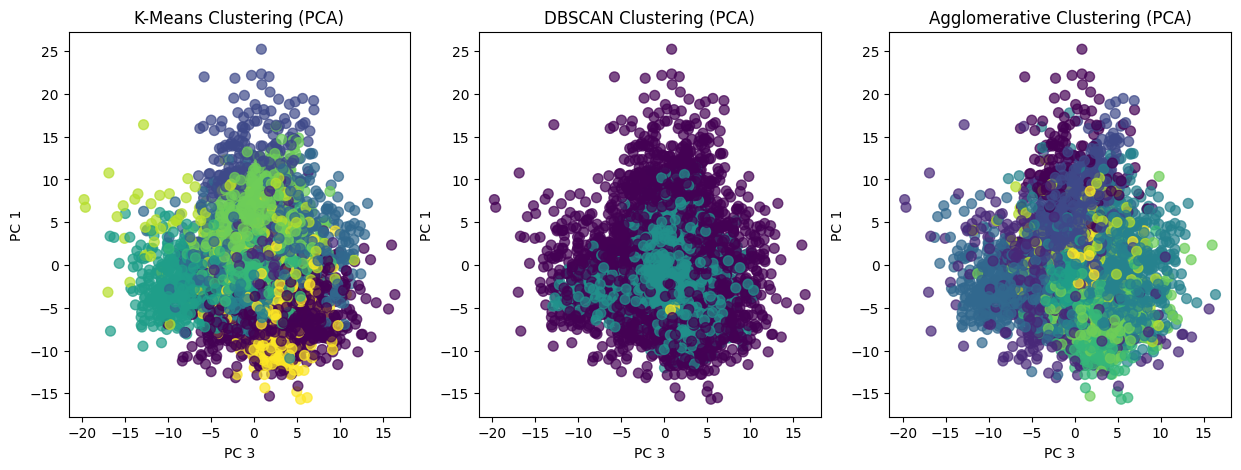

In [93]:
label_map = {
    "K-Means": labels_kmeans_pca,
    "DBSCAN": labels_dbscan_pca,
    "Agglomerative": labels_agglom_pca
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, (title, labels) in enumerate(label_map.items()):
    axes[i].scatter(
        X_pca_transformed[:, pc_x],
        X_pca_transformed[:, pc_y],
        c=labels,
        cmap="viridis",
        s=50,
        alpha=0.7
    )
    axes[i].set_title(f"{title} Clustering (PCA)")
    axes[i].set_xlabel(f"PC {pc_x}")
    axes[i].set_ylabel(f"PC {pc_y}")

## Final Reflection

- Which clustering algorithm appears to have performed the best?
  - Is there any tuning you tried that might have influenced this outcome?
- Based on the Adjusted Rand Index and Silhouette scores, did PCA appear to help here?
  - Does trying different numbers of principal components or required variance change the outcome?

Agglomerative clustering performed best overall because it produced the highest Adjusted Rand Index both before and after PCA, although K-Means had the highest silhouette scores.

I only tuned the DBSCAN, I started with a low eps value of 0.1 and was getting an index of 0, so I figured this was much too small, and kept multipling eps by ten until index stopped improving, then lowered it to find the best value. This turned out to be 15. For min samples, I tried 4 values 5, 10, 20 and 50. The best one was 20. For the other types, I didn't do much tuning beyond the recomended value from the instructions. If I tuned, they might have worked better.


PCA did not consistently improve performance: it slightly improved Agglomerative clustering but lowered the ARI for K-Means and DBSCAN. Trying different component counts or variance thresholds could change the results, so additional testing would be needed to determine the best PCA setting.

Most principal components pairs looked very similar, with only one being noticibly worse. There are small shifts in where each cluster starts and how many clusters there are between each component.